# 03 SQL 查询与主题分析

## 目的
- 基于数据库完成任务书规定查询，并形成主题分析结论与可视化图表。

## 方法
- 执行 3 个必做 SQL + 2 个自定义 SQL。
- 绘制收益率利差图与利率-汇率对比图。
- 识别加息/降息区间并统计汇率平均变动。

## 结果
- 得到结构化查询结果与关键图表输出（`output/`）。
- 形成“加息周期与汇率关系”的定量统计结果。

## 结论
- 本阶段完成“从 SQL 到业务解释”的分析闭环，可直接用于课程报告提交。

## 必做 SQL（含业务注释）

### 查询 1：美国收益率曲线利差（10Y - 2Y）
**业务含义**：用于观察长短端利率结构变化，判断经济预期与衰退信号。

```sql
-- 查询1：计算美国收益率曲线利差（10Y - 2Y）的月度时序
SELECT date,
       MAX(CASE WHEN series_id='DGS10' THEN value END) -
       MAX(CASE WHEN series_id='DGS2'  THEN value END) AS spread_10_2
FROM macro_data
GROUP BY date
ORDER BY date;
```

### 查询 2：每只股票年度平均收盘价和总成交量
**业务含义**：从价格中枢与成交活跃度评估股票年度交易特征。

```sql
-- 查询2：计算每只股票的年度平均收盘价和总成交量
SELECT code, substr(date,1,4) AS year,
       AVG(adj_close) AS avg_close,
       SUM(volume)    AS total_volume
FROM stock_price
GROUP BY code, year
ORDER BY code, year;
```

### 查询 3：特定行业中上市超过 10 年的股票
**业务含义**：按当前数据口径筛选货币金融服务行业中上市超过 10 年的股票。

```sql
-- 查询3：筛选出特定行业中，上市超过 10 年的股票
SELECT s.code, s.name, s.industry, s.list_date
FROM stock_info s
WHERE s.industry LIKE '%货币金融服务%'
  AND (julianday('now') - julianday(s.list_date)) / 365.0 > 10;
```


In [1]:
# 本单元：导入 SQL 分析与可视化依赖并建立数据库连接。
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from topic10_workflow import (
    analyze_hike_cycle_fx,
    run_custom_sql_queries,
    run_required_sql_queries,
    sqlite_connect,
)

project_dir = Path('.').resolve()
output_dir = project_dir / 'output'
output_dir.mkdir(exist_ok=True, parents=True)
conn = sqlite_connect(project_dir / 'fin_data.db')

In [2]:
# 本单元：执行任务书要求的三个必做 SQL 查询。
# 必做 SQL 查询
required = run_required_sql_queries(conn)
for k, df in required.items():
    print(k, df.shape)
    display(df.head())

query1 (315, 2)


,date,spread_10_2
0,2000-01-31,0.07
1,2000-02-29,-0.11
2,2000-03-31,-0.47
3,2000-04-30,-0.45
4,2000-05-31,-0.40


query2 (178, 4)


,code,year,avg_close,total_volume
0,sh.000300,2010,3082.966938,1.638844e+12
1,sh.000300,2011,2928.926037,1.315630e+12
2,sh.000300,2012,2424.779535,1.126478e+12
3,sh.000300,2013,2442.086887,1.717478e+12
4,sh.000300,2014,2372.951351,2.922214e+12


query3 (1, 4)


,code,name,industry,list_date
0,sh.600036,招商银行,J66货币金融服务,2002-04-09


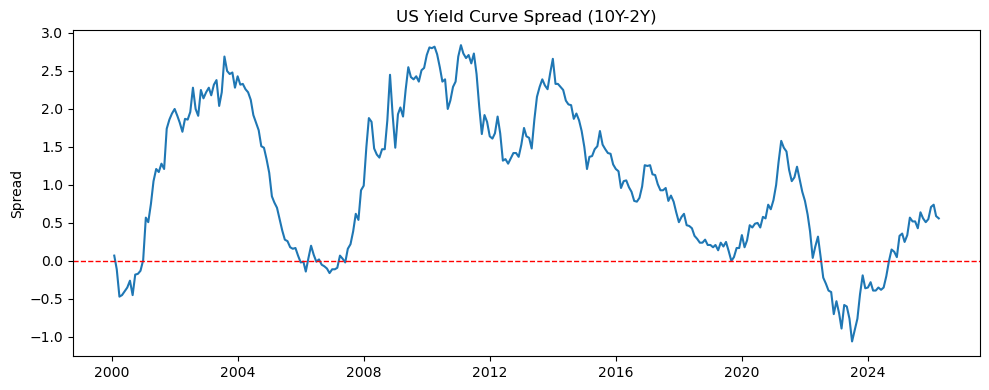

In [3]:
# 本单元：绘制收益率曲线利差时序图并导出图片。
# 查询1 可视化：10Y-2Y 利差
q1 = required['query1'].copy()
if not q1.empty:
    q1['date'] = pd.to_datetime(q1['date'])
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(q1['date'], q1['spread_10_2'])
    ax.axhline(0, color='red', ls='--', lw=1)
    ax.set_title('US Yield Curve Spread (10Y-2Y)')
    ax.set_ylabel('Spread')
    fig.tight_layout()
    fig.savefig(output_dir / 'query1_spread.png', dpi=150)
    plt.show()
else:
    print('macro_data 为空，无法绘图。')

In [4]:
# 本单元：执行两个自定义 SQL 查询用于扩展分析。
# 自定义 SQL 查询
custom = run_custom_sql_queries(conn)
for k, df in custom.items():
    print(k, df.shape)
    display(df.head())

query4 (1827, 4)


,code,ym,avg_daily_return,volatility
0,sh.600036,2010-01,-0.007905,0.020334
1,sh.600036,2010-02,0.003250,0.014957
2,sh.600036,2010-03,0.001261,0.021358
3,sh.600036,2010-04,-0.006078,0.018610
4,sh.600036,2010-05,-0.003531,0.022090


query5 (161, 6)


,code,name,year,annual_return,hs300_return,excess_return
0,sh.600036,招商银行,2010,-0.276680,-0.115118,-0.161562
1,sh.600036,招商银行,2011,-0.088326,-0.264584,0.176259
2,sh.600036,招商银行,2012,0.178235,0.097531,0.080704
3,sh.600036,招商银行,2013,-0.195122,-0.077001,-0.118121
4,sh.600036,招商银行,2014,0.546132,0.521851,0.024281


cycle_df shape: (315, 7)
cycle_summary shape: (2, 2)


,cycle_type,avg_fx_change
0,cut,-0.001385
1,hike,0.000713


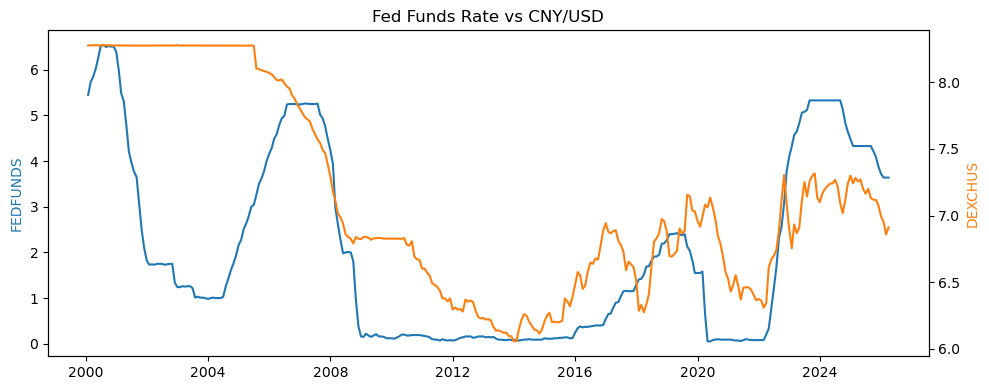

In [5]:
# 本单元：执行主题分析并绘制联邦基金利率与汇率对比图。
# 主题分析：美联储加息周期 vs 人民币汇率
cycle_df, cycle_summary = analyze_hike_cycle_fx(conn)
print('cycle_df shape:', cycle_df.shape)
print('cycle_summary shape:', cycle_summary.shape)
display(cycle_summary)

if not cycle_df.empty:
    fig, ax1 = plt.subplots(figsize=(10,4))
    ax1.plot(cycle_df['date'], cycle_df['fedfunds'], label='FEDFUNDS', color='tab:blue')
    ax1.set_ylabel('FEDFUNDS', color='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(cycle_df['date'], cycle_df['dexchus'], label='DEXCHUS', color='tab:orange')
    ax2.set_ylabel('DEXCHUS', color='tab:orange')

    plt.title('Fed Funds Rate vs CNY/USD')
    fig.tight_layout()
    fig.savefig(output_dir / 'fed_vs_fx.png', dpi=150)
    plt.show()
else:
    print('宏观数据不足，无法完成主题图。')

In [6]:
# 本单元：自动生成本 Notebook 的真实结果结论（随运行结果变化）。
from IPython.display import Markdown, display

q1_rows = len(required['query1'])
q2_rows = len(required['query2'])
q3_rows = len(required['query3'])
q4_rows = len(custom['query4'])
q5_rows = len(custom['query5'])

cycle_text = '暂无可用周期统计（请检查 macro_data 是否已更新）。'
if not cycle_summary.empty:
    cycle_text = '; '.join([f"{r['cycle_type']}={r['avg_fx_change']:.6f}" for _, r in cycle_summary.iterrows()])

summary_text = f"""
### 自动结论（真实结果）
- 必做查询返回行数：Q1={q1_rows}，Q2={q2_rows}，Q3={q3_rows}
- 自定义查询返回行数：Q4={q4_rows}，Q5={q5_rows}
- 主题分析周期统计：{cycle_text}

结论：SQL 查询与主题分析流程已完成，结果可直接用于报告撰写与图表展示。
"""
display(Markdown(summary_text))


### 自动结论（真实结果）
- 必做查询返回行数：Q1=315，Q2=178，Q3=1
- 自定义查询返回行数：Q4=1827，Q5=161
- 主题分析周期统计：cut=-0.001385; hike=0.000713

结论：SQL 查询与主题分析流程已完成，结果可直接用于报告撰写与图表展示。


In [7]:
# 本单元：关闭数据库连接，释放资源。
conn.close()